# Shadow Comparison Plots

Two custom comparison figures built from the same `.npz` results used in
`Shadow_Simulations_Results.ipynb`, re-cut to answer two specific
questions:

1. **How does the CSPSA optimization behave as $N_{\rm sh}$ changes,
   comparing the Mix (Shadow-Exact) and Full Shadow evaluations side by
   side?** Built from Sim01_04 (maximally entangled state).
2. **How well does the Shadow evaluation alone track the classical and
   quantum bounds, for every Schmidt/Werner parameter value at once?**
   Built from Sim02_03_02 (Schmidt) and Sim03_03_02 (Werner), both at
   $N_{\rm sh}=10^6$, zoomed in near the bounds.

As before, no simulation is re-run here; only existing `.npz` files are
loaded and plotted. Figures are saved as PDF into a new
`Figuras_Comparison/` folder.

In [55]:
import os

import numpy as np

import matplotlib
matplotlib.rcParams['text.usetex'] = True
import matplotlib.pyplot as plt

APS_FONT_SIZE = 9   # pt, matches the two-column manuscript body text
plt.rcParams.update({
    'font.size': APS_FONT_SIZE,
    'axes.titlesize': APS_FONT_SIZE,
    'axes.labelsize': APS_FONT_SIZE,
    'xtick.labelsize': APS_FONT_SIZE,
    'ytick.labelsize': APS_FONT_SIZE,
    'legend.fontsize': APS_FONT_SIZE,
    'figure.titlesize': APS_FONT_SIZE,
})

QUANTUM_MAX = (np.sqrt(2) - 1) / 16   # quantum maximum of the wagon-wheel functional
CLASSICAL_BOUND = 0                    # classical bound of the wagon-wheel inequality

FOLDER_MAXENT = "Simulacion_01"
FOLDER_SCHMIDT = "Simulacion_02"
FOLDER_WERNER = "Simulacion_03"

FIG_DIR = "Figuras_Comparison"
os.makedirs(FIG_DIR, exist_ok=True)

## Figure 1 — Sim01_04: algorithm comparison across $N_{\rm sh}$

**Source data:** `Simulacion_01/Sim01_04_N1e{3,4,5,6}.npz` (maximally
entangled state, `Out_mix`/`Out_sh` from the Shadow-guided optimization
block — see Simulation 01_04 in `Shadow_Simulations_Results.ipynb` for
the full description).

Two subplots, both using the default Matplotlib color cycle (`C0`-`C3`)
to identify $N_{\rm sh}$, the same convention used throughout
`Shadow_Simulations_Results.ipynb`:

- **Left — Median Shadow, all $N_{\rm sh}$ together:** the Full Shadow
  evaluation (gradient and functional both estimated via Classical
  Shadows) for every $N_{\rm sh}\in\{10^3,10^4,10^5,10^6\}$.
- **Right — Median Mix, all $N_{\rm sh}$ together:** the Shadow-Exact
  evaluation (Shadow-estimated gradient, exact evaluation of the
  trajectory) for the same four values of $N_{\rm sh}$.

Comparing the two subplots isolates how much of the residual gap to the
quantum maximum comes from the functional estimate itself (Shadow, left)
versus the gradient estimate driving the optimization (Mix, right).

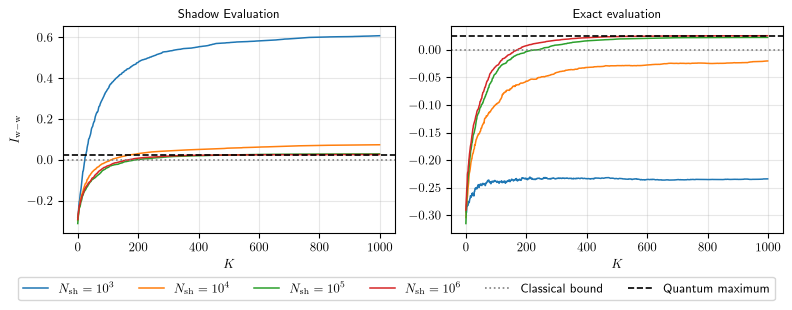

In [56]:
N_SH_EXPONENTS = [3, 4, 5, 6]
DEFAULT_COLORS = plt.rcParams['axes.prop_cycle'].by_key()['color']
NSH_COLORS = dict(zip(N_SH_EXPONENTS, DEFAULT_COLORS))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8.0, 3.2))

for exponent in N_SH_EXPONENTS:
    path = f"{FOLDER_MAXENT}/Sim01_04_N1e{exponent}.npz"
    Data = np.load(path)
    it = np.arange(len(Data['median_sh']))
    ax1.plot(it, Data['median_sh'], color=NSH_COLORS[exponent], linewidth=1.1,
              label=rf"$N_{{\rm sh}}=10^{exponent}$")

ax1.axhline(CLASSICAL_BOUND, color='gray', linestyle=':', linewidth=1.2, label="Classical bound")
ax1.axhline(QUANTUM_MAX, color='black', linestyle='--', linewidth=1.2, label="Quantum maximum")
ax1.set_xlabel(r"$K$")
ax1.set_ylabel(r"$I_{\rm w-w}$")
ax1.set_title("Shadow Evaluation")
ax1.grid(alpha=0.3)

for exponent in N_SH_EXPONENTS:
    path = f"{FOLDER_MAXENT}/Sim01_04_N1e{exponent}.npz"
    Data = np.load(path)
    it = np.arange(len(Data['median_mix']))
    ax2.plot(it, Data['median_mix'], color=NSH_COLORS[exponent], linewidth=1.1,
             label=rf"$N_{{\rm sh}}=10^{exponent}$")

ax2.axhline(CLASSICAL_BOUND, color='gray', linestyle=':', linewidth=1.2)
ax2.axhline(QUANTUM_MAX, color='black', linestyle='--', linewidth=1.2)
ax2.set_xlabel(r"$K$")
ax2.set_title("Exact evaluation")
ax2.grid(alpha=0.3)

# single shared legend outside the subplots (both panels use the same N_sh series)
handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=6,
           bbox_to_anchor=(0.5, 0.03), frameon=True)

fig.tight_layout(rect=[0, 0.1, 1, 1])
fig.savefig(os.path.join(FIG_DIR, "figure_1.pdf"), bbox_inches='tight')
plt.show()

## Figure 2 — Sim02_03_02 / Sim03_03_02: Shadow evaluation near the bounds

**Source data:** `Simulacion_02/Sim02_03_02_a{val}_N1e6.npz` (Schmidt,
refined grid) and `Simulacion_03/Sim03_03_02_p{val}_N1e6.npz` (Werner,
refined grid), both at $N_{\rm sh}=10^6$ — see Simulations 02_03_02 and
03_03_02 in `Shadow_Simulations_Results.ipynb`.

Two subplots, one per state family, each overlaying **every parameter
value** of that family on the same axes, showing **only the Shadow
evaluation** (`median_sh`). The y-axis is zoomed to the region near the
classical bound ($I_{\rm w-w}=0$) and the quantum maximum, computed
automatically from the tail of all curves (Schmidt and Werner combined)
so **both subplots share the same $y$-limits**, making the two state
families directly comparable at a glance.

In [57]:
def compute_zoom_ylim(curves, tail_fraction=0.3, pad_fraction=0.15):
    """
    Zoom the y-axis to the region spanned by the last `tail_fraction` of
    each curve (where the curves have mostly converged), together with
    the classical bound and the quantum maximum, padded by
    `pad_fraction` of the resulting range.
    """
    tail_values = []
    for curve in curves:
        n_tail = max(1, int(len(curve) * tail_fraction))
        tail_values.append(curve[-n_tail:])
    tail_values = np.concatenate(tail_values)

    lo = min(tail_values.min(), CLASSICAL_BOUND, QUANTUM_MAX)
    hi = max(tail_values.max(), CLASSICAL_BOUND, QUANTUM_MAX)
    pad = (hi - lo) * pad_fraction
    return lo - pad, hi + pad

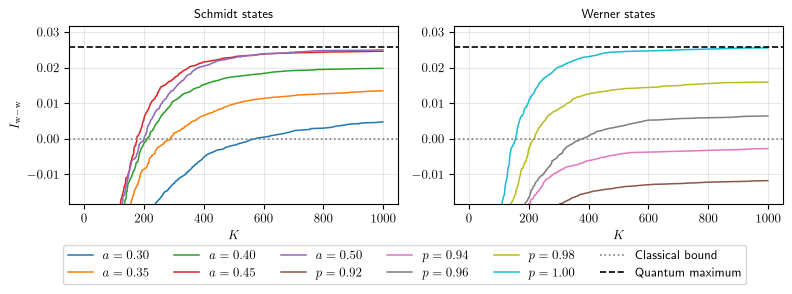

In [59]:
A_VALUES = [0.30, 0.35, 0.40, 0.45, 0.50]
P_VALUES = [0.92, 0.94, 0.96, 0.98, 1.00]

# one shared qualitative palette across all curves in this figure, so no
# color is reused between the Schmidt and Werner subplots
ALL_COLORS = plt.cm.tab10(np.linspace(0, 1, len(A_VALUES) + len(P_VALUES)))
colors_a = ALL_COLORS[:len(A_VALUES)]
colors_p = ALL_COLORS[len(A_VALUES):]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8.0, 3.2))

curves_schmidt = []
for a, color in zip(A_VALUES, colors_a):
    path = f"{FOLDER_SCHMIDT}/Sim02_03_02_a{a:.2f}_N1e6.npz"
    Data = np.load(path)
    median_sh = Data['median_sh']
    curves_schmidt.append(median_sh)
    it = np.arange(len(median_sh))
    ax1.plot(it, median_sh, color=color, linewidth=1.1, label=rf"$a={a:.2f}$")

ax1.axhline(CLASSICAL_BOUND, color='gray', linestyle=':', linewidth=1.2, )
ax1.axhline(QUANTUM_MAX, color='black', linestyle='--', linewidth=1.2, )
ax1.set_xlabel(r"$K$")
ax1.set_ylabel(r"$I_{\rm w-w}$")
ax1.set_title(r"Schmidt states")
ax1.grid(alpha=0.3)

curves_werner = []
for p, color in zip(P_VALUES, colors_p):
    path = f"{FOLDER_WERNER}/Sim03_03_02_p{p:.2f}_N1e6.npz"
    Data = np.load(path)
    median_sh = Data['median_sh']
    curves_werner.append(median_sh)
    it = np.arange(len(median_sh))
    ax2.plot(it, median_sh, color=color, linewidth=1.1, label=rf"$p={p:.2f}$")

ax2.axhline(CLASSICAL_BOUND, color='gray', linestyle=':', linewidth=1.2, label="Classical bound")
ax2.axhline(QUANTUM_MAX, color='black', linestyle='--', linewidth=1.2, label="Quantum maximum")
ax2.set_xlabel(r"$K$")
ax2.set_title(r"Werner states")
ax2.grid(alpha=0.3)

shared_ylim = compute_zoom_ylim(curves_schmidt + curves_werner)
ax1.set_ylim(shared_ylim)
ax2.set_ylim(shared_ylim)

# single shared legend outside the subplots, deduplicating the bound
# labels that both panels share (a and p entries are panel-specific)
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
combined = {}
for h, l in zip(handles1 + handles2, labels1 + labels2):
    combined.setdefault(l, h)
fig.legend(combined.values(), combined.keys(), loc='lower center', ncol=6,
           bbox_to_anchor=(0.51, 0.01), frameon=True )

fig.tight_layout(rect=[0, 0.12, 1, 0.93])
fig.savefig(os.path.join(FIG_DIR, "figure_2.pdf"), bbox_inches='tight')
plt.show()